# Mini-Project 1 - Advanced Python Data Exploration & Automated Reporting

## Phase 0 - Setup
This notebook analyzes the Sample Superstore 2019 dataset using Pandas, NumPy, Matplotlib, and Seaborn.

In [1]:
from pathlib import Path
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / 'data'
OUTPUT_DIR = PROJECT_DIR / 'output'
CHARTS_DIR = OUTPUT_DIR / 'charts'
RAW_DATA_PATH = PROJECT_DIR / 'Sample - Superstore 2019.xls'

for path in (DATA_DIR, OUTPUT_DIR, CHARTS_DIR):
    path.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

logging.basicConfig(level=logging.INFO, format='%(levelname)s:%(message)s')
logger = logging.getLogger('mini_project_1')

logger.info('Phase 0 setup complete')

INFO:Phase 0 setup complete


## Phase 1 - Import & Inspect Data
Load the Excel dataset with exception handling, then inspect structure, metadata, missing values, and duplicate records.

In [2]:
try:
    df = pd.read_excel(RAW_DATA_PATH)
    logger.info('Loaded dataset with %s rows and %s columns', *df.shape)
except FileNotFoundError as exc:
    logger.error('Dataset file not found: %s', RAW_DATA_PATH)
    raise exc
except Exception as exc:
    logger.error('Could not load dataset: %s', exc)
    raise exc

df.head()

INFO:Loaded dataset with 9994 rows and 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Shape: (9994, 21)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data types:
Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
Country/Region            object
City                      object
State                     object
Postal Code              float64
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   object        
 2   Order Date      9994 non-null   datetime64[ns]
 3   Ship Date       9994 non-null   datetime64[ns]
 4   Ship Mode       9994 non-null   object        
 5   Customer ID     9994 non-null   object        
 6   Customer Name   9994 non-null   object        
 7   Segment         9994 non-null   object        
 8   Country/Region  9994 non-null   object        
 9   City            9994 non-null   object        
 10  State           9994 non-null   object        
 11  Postal Code     9983 non-null   float64       
 12  Region          9994 non-null   object        
 13  Product ID      9994 non-null   object        
 14  Category        9994 non-null   object        
 15  Sub-

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Row ID,9994.0,NaN,NaN,NaN,4997.5,1.0,2499.25,4997.5,7495.75,9994.0,2885.163629
Order ID,9994,5009,CA-2019-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9994,NaN,NaN,NaN,2018-04-30 10:03:51.979187712,2016-01-03 00:00:00,2017-05-23 00:00:00,2018-06-26 00:00:00,2019-05-14 00:00:00,2019-12-30 00:00:00,NaN
Ship Date,9994,NaN,NaN,NaN,2018-05-04 09:03:29.645787392,2016-01-07 00:00:00,2017-05-27 00:00:00,2018-06-29 00:00:00,2019-05-18 00:00:00,2020-01-05 00:00:00,NaN
Ship Mode,9994,4,Standard Class,5968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9994,793,WB-21850,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9994,793,William Brown,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9994,3,Consumer,5191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country/Region,9994,1,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9994,531,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2016-110422,2016-01-21,2016-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180.0,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2019-119914,2019-05-04,2019-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683.0,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


### Initial Observations
- Review missing-value counts before choosing cleaning rules.
- Check date columns after loading to confirm they parsed correctly.
- Check duplicate count before removing records in Phase 3.
- Numeric summaries will guide outlier handling for Sales, Profit, Discount, and Quantity.

## Phase 2 - OOP Structure
Define small classes for loading, cleaning, feature engineering, analysis, visualization, and reporting. Later phases will fill in the detailed methods.

In [7]:
class DataLoader:
    def __init__(self, path):
        self.path = Path(path)

    def load(self):
        try:
            data = pd.read_excel(self.path)
            logger.info('Loaded %s rows and %s columns from %s', *data.shape, self.path.name)
            return data
        except FileNotFoundError as exc:
            logger.error('Dataset file not found: %s', self.path)
            raise exc
        except Exception as exc:
            logger.error('Could not load dataset: %s', exc)
            raise exc


class DataCleaner:
    def __init__(self, data):
        self.df = data.copy()

    def run_pipeline(self):
        return self.df


class FeatureEngineer:
    def __init__(self, data):
        self.df = data.copy()

    def run_pipeline(self):
        return self.df


class EDAAnalyzer:
    def __init__(self, data):
        self.df = data


class Visualizer:
    def __init__(self, data, charts_dir):
        self.df = data
        self.charts_dir = Path(charts_dir)


class ReportGenerator:
    def __init__(self, data, output_dir):
        self.df = data
        self.output_dir = Path(output_dir)


In [8]:
loader = DataLoader(RAW_DATA_PATH)
df = loader.load()

cleaner = DataCleaner(df)
feature_engineer = FeatureEngineer(df)
eda = EDAAnalyzer(df)
visualizer = Visualizer(df, CHARTS_DIR)
reporter = ReportGenerator(df, OUTPUT_DIR)

print('Phase 2 OOP objects ready:', type(loader).__name__, type(cleaner).__name__, type(feature_engineer).__name__, type(eda).__name__, type(visualizer).__name__, type(reporter).__name__)

INFO:Loaded 9994 rows and 21 columns from Sample - Superstore 2019.xls


Phase 2 OOP objects ready: DataLoader DataCleaner FeatureEngineer EDAAnalyzer Visualizer ReportGenerator


## Phase 3 - Advanced Data Cleaning
Clean missing values, duplicate records, text/date formats, and outliers through reusable `DataCleaner` methods.

In [9]:
class DataCleaner:
    def __init__(self, data):
        self.df = data.copy()

    def handle_missing_values(self):
        try:
            missing_before = self.df.isna().sum()
            if 'Postal Code' in self.df.columns:
                self.df['Postal Code'] = self.df['Postal Code'].fillna('Unknown').astype(str)
            for col in self.df.select_dtypes(include=['number']).columns:
                if self.df[col].isna().any():
                    self.df[col] = self.df[col].fillna(self.df[col].median())
            for col in self.df.select_dtypes(include=['object']).columns:
                if self.df[col].isna().any():
                    mode = self.df[col].mode(dropna=True)
                    self.df[col] = self.df[col].fillna(mode.iloc[0] if not mode.empty else 'Unknown')
            logger.info('Missing values before cleaning: %s', int(missing_before.sum()))
            return self
        except Exception as exc:
            logger.error('Missing-value handling failed: %s', exc)
            raise exc

    def remove_duplicates(self):
        try:
            before = len(self.df)
            self.df = self.df.drop_duplicates()
            logger.info('Removed %s duplicate rows', before - len(self.df))
            return self
        except Exception as exc:
            logger.error('Duplicate removal failed: %s', exc)
            raise exc

    def standardize_formats(self):
        try:
            for col in self.df.select_dtypes(include=['object']).columns:
                if col.endswith('ID') or col == 'Postal Code':
                    self.df[col] = self.df[col].astype(str).str.strip()
                else:
                    self.df[col] = self.df[col].astype(str).str.strip()
            for col in ['Order Date', 'Ship Date']:
                if col in self.df.columns:
                    self.df[col] = pd.to_datetime(self.df[col], errors='coerce')
            logger.info('Standardized text and date formats')
            return self
        except Exception as exc:
            logger.error('Format standardization failed: %s', exc)
            raise exc

    def flag_outliers(self, columns=None):
        try:
            columns = columns or ['Sales', 'Profit', 'Discount', 'Quantity']
            for col in columns:
                if col not in self.df.columns:
                    continue
                q1, q3 = self.df[col].quantile([0.25, 0.75])
                iqr = q3 - q1
                lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
                self.df[f'{col} Outlier'] = ~self.df[col].between(lower, upper)
                logger.info('%s outliers flagged in %s', int(self.df[f'{col} Outlier'].sum()), col)
            return self
        except Exception as exc:
            logger.error('Outlier flagging failed: %s', exc)
            raise exc

    def run_pipeline(self):
        return (self.handle_missing_values()
                    .remove_duplicates()
                    .standardize_formats()
                    .flag_outliers()
                    .df)


In [10]:
cleaner = DataCleaner(df)
df_clean = cleaner.run_pipeline()

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Remaining missing values:", int(df_clean.isna().sum().sum()))
print("Duplicate rows:", int(df_clean.duplicated().sum()))
df_clean[['Sales Outlier', 'Profit Outlier', 'Discount Outlier', 'Quantity Outlier']].sum()

INFO:Missing values before cleaning: 11


INFO:Removed 0 duplicate rows


INFO:Standardized text and date formats


INFO:1167 outliers flagged in Sales


INFO:1881 outliers flagged in Profit


INFO:856 outliers flagged in Discount


INFO:170 outliers flagged in Quantity


Original shape: (9994, 21)
Cleaned shape: (9994, 25)
Remaining missing values: 0
Duplicate rows: 0


Sales Outlier       1167
Profit Outlier      1881
Discount Outlier     856
Quantity Outlier     170
dtype: int64

### Cleaning Notes
- Missing `Postal Code` values were filled with `Unknown` because postal codes are identifiers, not numeric measures.
- Exact duplicate rows were removed if found.
- Text fields were stripped of extra spaces and date fields were parsed as datetime values.
- Outliers were flagged with the IQR method instead of removed, preserving real high-value orders for business analysis.

## Phase 4 - Feature Engineering
Create reusable feature-engineering methods for profit margin, shipping duration, sales performance categories, and simple date features.

In [11]:
class FeatureEngineer:
    def __init__(self, data):
        self.df = data.copy()

    def add_profit_margin(self):
        try:
            self.df['Profit Margin'] = np.where(self.df['Sales'].ne(0), self.df['Profit'] / self.df['Sales'], 0)
            logger.info('Added Profit Margin')
            return self
        except Exception as exc:
            logger.error('Profit Margin creation failed: %s', exc)
            raise exc

    def add_shipping_duration(self):
        try:
            self.df['Shipping Duration'] = (self.df['Ship Date'] - self.df['Order Date']).dt.days
            logger.info('Added Shipping Duration')
            return self
        except Exception as exc:
            logger.error('Shipping Duration creation failed: %s', exc)
            raise exc

    def add_sales_performance_category(self):
        try:
            labels = ['Low', 'Medium', 'High']
            self.df['Sales Performance Category'] = pd.qcut(self.df['Sales'], q=3, labels=labels)
            logger.info('Added Sales Performance Category')
            return self
        except ValueError:
            self.df['Sales Performance Category'] = pd.cut(self.df['Sales'], bins=3, labels=['Low', 'Medium', 'High'])
            logger.info('Added Sales Performance Category with equal-width bins')
            return self
        except Exception as exc:
            logger.error('Sales Performance Category creation failed: %s', exc)
            raise exc

    def add_date_features(self):
        try:
            self.df['Order Year'] = self.df['Order Date'].dt.year
            self.df['Order Month'] = self.df['Order Date'].dt.to_period('M').astype(str)
            logger.info('Added Order Year and Order Month')
            return self
        except Exception as exc:
            logger.error('Date feature creation failed: %s', exc)
            raise exc

    def run_pipeline(self):
        return (self.add_profit_margin()
                    .add_shipping_duration()
                    .add_sales_performance_category()
                    .add_date_features()
                    .df)


In [12]:
feature_engineer = FeatureEngineer(df_clean)
df_enriched = feature_engineer.run_pipeline()

new_columns = ['Profit Margin', 'Shipping Duration', 'Sales Performance Category', 'Order Year', 'Order Month']
print("Enriched shape:", df_enriched.shape)
print(df_enriched[new_columns].head())
print("\nSales Performance Category counts:")
print(df_enriched['Sales Performance Category'].value_counts())

INFO:Added Profit Margin


INFO:Added Shipping Duration


INFO:Added Sales Performance Category


INFO:Added Order Year and Order Month


Enriched shape: (9994, 30)
   Profit Margin  Shipping Duration Sales Performance Category  Order Year  \
0         0.1600                  3                       High        2018   
1         0.3000                  3                       High        2018   
2         0.4700                  4                        Low        2018   
3        -0.4000                  7                       High        2017   
4         0.1125                  7                        Low        2017   

  Order Month  
0     2018-11  
1     2018-11  
2     2018-06  
3     2017-10  
4     2017-10  

Sales Performance Category counts:
Sales Performance Category
High      3332
Low       3331
Medium    3331
Name: count, dtype: int64


### Feature Notes
- `Profit Margin` measures profit relative to sales and safely handles zero sales.
- `Shipping Duration` measures delivery time in days between order and ship dates.
- `Sales Performance Category` splits orders into Low, Medium, and High sales groups using quantiles.
- `Order Year` and `Order Month` support trend analysis in later phases.

## Phase 5 - Exploratory Data Analysis
Use reusable analysis methods for numeric distributions, categorical performance, time trends, and correlation analysis.

In [13]:
class EDAAnalyzer:
    def __init__(self, data):
        self.df = data.copy()

    def numeric_summary(self):
        cols = ['Sales', 'Profit', 'Discount', 'Quantity', 'Profit Margin', 'Shipping Duration']
        return self.df[cols].describe().T

    def category_summary(self, group_col):
        try:
            return (self.df.groupby(group_col, observed=True)
                    .agg(Orders=('Order ID', 'nunique'),
                         Sales=('Sales', 'sum'),
                         Profit=('Profit', 'sum'),
                         Average_Discount=('Discount', 'mean'),
                         Average_Shipping_Duration=('Shipping Duration', 'mean'))
                    .sort_values('Sales', ascending=False))
        except Exception as exc:
            logger.error('Category summary failed for %s: %s', group_col, exc)
            raise exc

    def monthly_trend(self):
        try:
            trend = (self.df.groupby('Order Month', observed=True)
                     .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'), Orders=('Order ID', 'nunique'))
                     .reset_index())
            trend['Order Month'] = pd.to_datetime(trend['Order Month'])
            return trend.sort_values('Order Month')
        except Exception as exc:
            logger.error('Monthly trend analysis failed: %s', exc)
            raise exc

    def correlation_matrix(self):
        cols = ['Sales', 'Profit', 'Discount', 'Quantity', 'Profit Margin', 'Shipping Duration']
        return self.df[cols].corr(numeric_only=True)


In [14]:
eda = EDAAnalyzer(df_enriched)
numeric_summary = eda.numeric_summary()
numeric_summary

,count,mean,std,min,25%,50%,75%,max
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.9400,22638.480
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.3640,8399.976
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.2000,0.800
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.0000,14.000
Profit Margin,9994.0,0.120314,0.466754,-2.750,0.07500,0.2700,0.3625,0.500
Shipping Duration,9994.0,3.958075,1.747937,0.000,3.00000,4.0000,5.0000,7.000


In [15]:
category_performance = eda.category_summary('Category')
region_performance = eda.category_summary('Region')
segment_performance = eda.category_summary('Segment')
category_performance

,Orders,Sales,Profit,Average_Discount,Average_Shipping_Duration
Category,,,,,
Technology,1544,836154.0330,145454.9481,0.132323,3.923119
Furniture,1764,741999.7953,18451.2728,0.173923,3.916549
Office Supplies,3742,719047.0320,122490.8008,0.157285,3.983405


In [16]:
subcategory_performance = eda.category_summary('Sub-Category')
subcategory_performance.head(10)

,Orders,Sales,Profit,Average_Discount,Average_Shipping_Duration
Sub-Category,,,,,
Phones,814,330007.0540,44515.7306,0.154556,4.001125
Chairs,576,328449.1030,26590.1663,0.170178,3.899514
Storage,777,223843.6080,21278.8264,0.074704,3.975177
Tables,307,206965.5320,-17725.4811,0.261285,3.893417
Binders,1316,203412.7330,30221.7633,0.372292,4.021668
Machines,112,189238.6310,3384.7569,0.306087,3.747826
Accessories,718,167380.3180,41936.6357,0.078452,3.886452
Copiers,68,149528.0300,55617.8249,0.161765,3.617647
Bookcases,224,114879.9963,-3472.5560,0.211140,3.811404


In [17]:
monthly_trend = eda.monthly_trend()
monthly_trend.head()

,Order Month,Sales,Profit,Orders
0,2016-01-01,14236.895,2450.1907,32
1,2016-02-01,4519.892,862.3084,28
2,2016-03-01,55691.009,498.7299,71
3,2016-04-01,28295.345,3488.8352,66
4,2016-05-01,23648.287,2738.7096,69


In [18]:
correlation_matrix = eda.correlation_matrix()
correlation_matrix

,Sales,Profit,Discount,Quantity,Profit Margin,Shipping Duration
Sales,1.000000,0.479064,-0.028190,0.200795,0.003444,-0.007350
Profit,0.479064,1.000000,-0.219487,0.066253,0.223732,-0.004658
Discount,-0.028190,-0.219487,1.000000,0.008623,-0.864452,0.000452
Quantity,0.200795,0.066253,0.008623,1.000000,-0.005280,0.018315
Profit Margin,0.003444,0.223732,-0.864452,-0.005280,1.000000,-0.011800
Shipping Duration,-0.007350,-0.004658,0.000452,0.018315,-0.011800,1.000000


### EDA Notes
- Numeric summaries show sales and profit are highly skewed, so medians and outlier flags matter.
- Category, region, and segment summaries identify where revenue and profit are concentrated.
- Monthly trend data prepares the time-series visualization and business trend discussion.
- The correlation matrix supports the required statistical analysis before visualization.

## Phase 6 - Visualizations
Create and automatically save at least eight visual reports using Matplotlib and Seaborn.

In [19]:
class Visualizer:
    def __init__(self, data, charts_dir):
        self.df = data.copy()
        self.charts_dir = Path(charts_dir)
        self.charts_dir.mkdir(parents=True, exist_ok=True)

    def _save(self, filename):
        path = self.charts_dir / filename
        plt.tight_layout()
        plt.savefig(path, dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
        return path

    def sales_distribution(self):
        plt.figure()
        sns.histplot(self.df['Sales'], bins=40, kde=True, color='steelblue')
        plt.title('Sales Distribution')
        plt.xlabel('Sales')
        return self._save('01_sales_distribution.png')

    def profit_boxplot(self):
        plt.figure()
        sns.boxplot(x=self.df['Profit'], color='indianred')
        plt.title('Profit Distribution and Outliers')
        return self._save('02_profit_boxplot.png')

    def sales_by_category(self):
        data = self.df.groupby('Category', observed=True)['Sales'].sum().sort_values(ascending=False)
        plt.figure()
        sns.barplot(x=data.index, y=data.values, hue=data.index, palette='Set2', legend=False)
        plt.title('Sales by Category')
        plt.ylabel('Total Sales')
        return self._save('03_sales_by_category.png')

    def profit_by_subcategory(self):
        data = self.df.groupby('Sub-Category', observed=True)['Profit'].sum().sort_values()
        plt.figure(figsize=(10, 7))
        sns.barplot(x=data.values, y=data.index, hue=data.index, palette='coolwarm', legend=False)
        plt.title('Profit by Sub-Category')
        plt.xlabel('Total Profit')
        return self._save('04_profit_by_subcategory.png')

    def monthly_sales_trend(self):
        trend = self.df.groupby('Order Month', observed=True)['Sales'].sum().reset_index()
        trend['Order Month'] = pd.to_datetime(trend['Order Month'])
        plt.figure(figsize=(11, 5))
        sns.lineplot(data=trend, x='Order Month', y='Sales', marker='o', color='seagreen')
        plt.title('Monthly Sales Trend')
        plt.xticks(rotation=45)
        return self._save('05_monthly_sales_trend.png')

    def correlation_heatmap(self):
        cols = ['Sales', 'Profit', 'Discount', 'Quantity', 'Profit Margin', 'Shipping Duration']
        plt.figure(figsize=(8, 6))
        sns.heatmap(self.df[cols].corr(), annot=True, cmap='vlag', center=0, fmt='.2f')
        plt.title('Correlation Heatmap')
        return self._save('06_correlation_heatmap.png')

    def sales_profit_scatter(self):
        plt.figure()
        sns.scatterplot(data=self.df, x='Sales', y='Profit', hue='Category', alpha=0.65)
        plt.title('Sales vs Profit by Category')
        return self._save('07_sales_profit_scatter.png')

    def performance_category_counts(self):
        plt.figure()
        sns.countplot(data=self.df, x='Sales Performance Category', hue='Sales Performance Category', palette='Set1', legend=False)
        plt.title('Sales Performance Category Counts')
        return self._save('08_sales_performance_counts.png')

    def shipping_duration_by_mode(self):
        plt.figure()
        sns.boxplot(data=self.df, x='Ship Mode', y='Shipping Duration', hue='Ship Mode', palette='Set3', legend=False)
        plt.title('Shipping Duration by Ship Mode')
        plt.xticks(rotation=20)
        return self._save('09_shipping_duration_by_mode.png')

    def create_all(self):
        try:
            paths = [
                self.sales_distribution(),
                self.profit_boxplot(),
                self.sales_by_category(),
                self.profit_by_subcategory(),
                self.monthly_sales_trend(),
                self.correlation_heatmap(),
                self.sales_profit_scatter(),
                self.performance_category_counts(),
                self.shipping_duration_by_mode(),
            ]
            logger.info('Saved %s charts to %s', len(paths), self.charts_dir)
            return paths
        except Exception as exc:
            logger.error('Visualization generation failed: %s', exc)
            raise exc


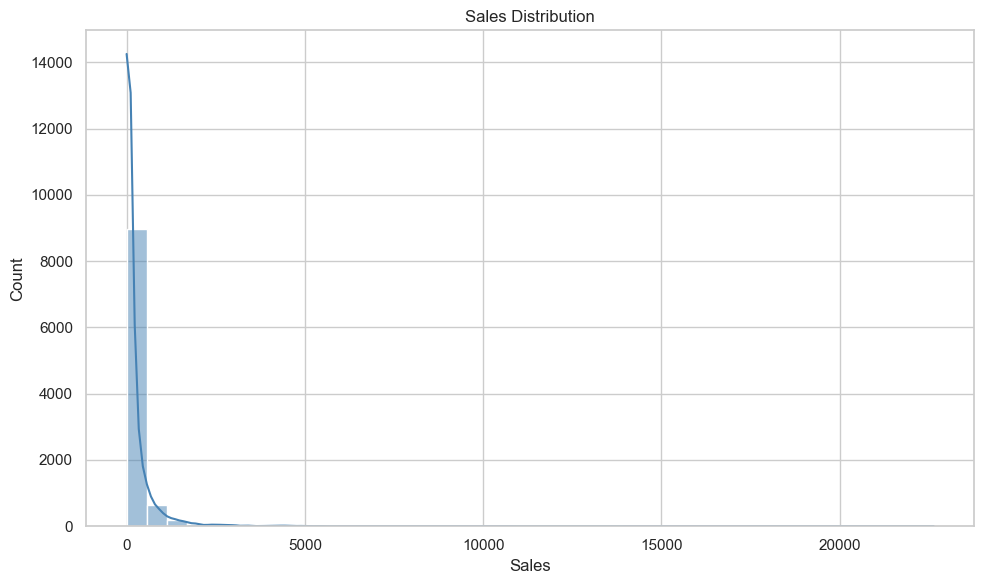

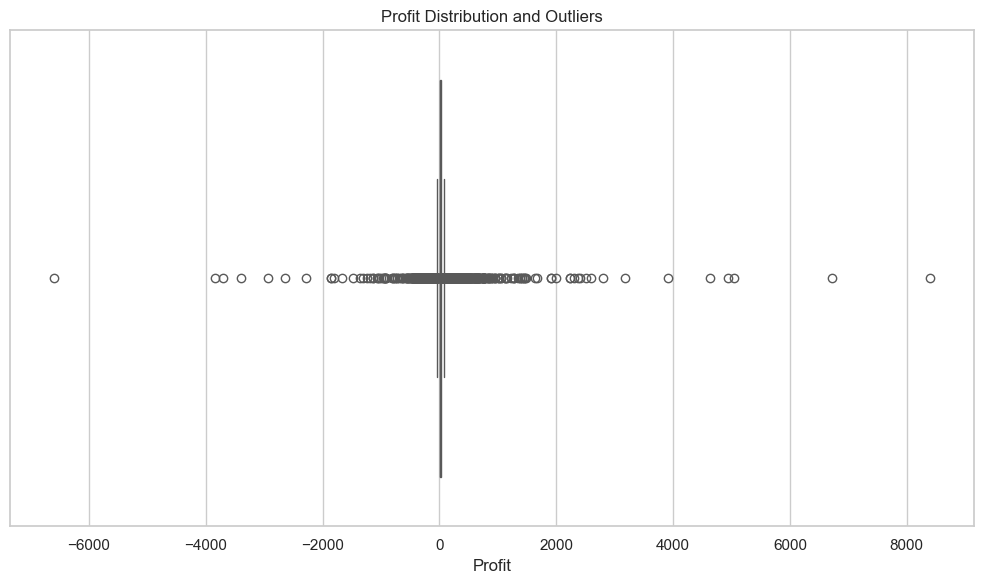

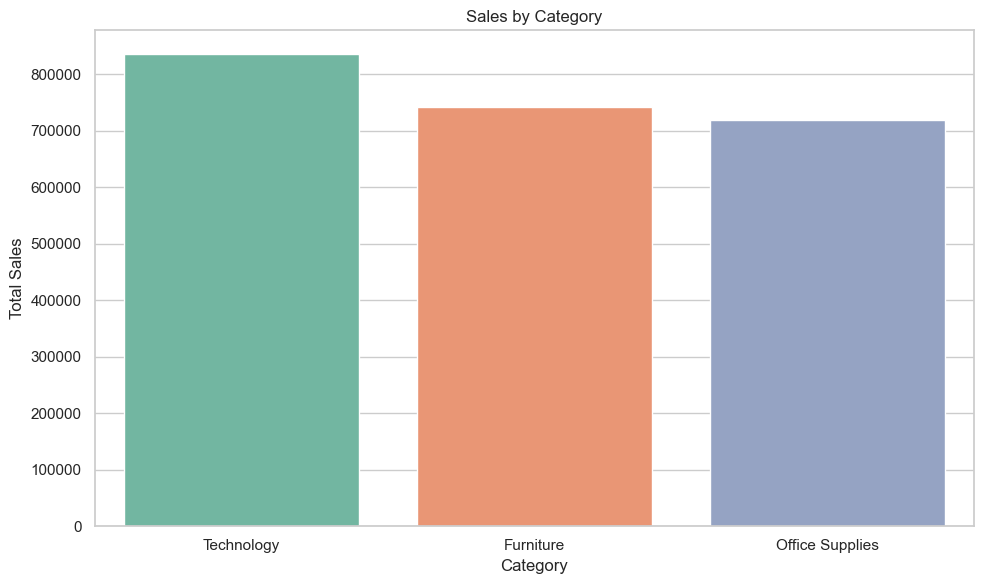

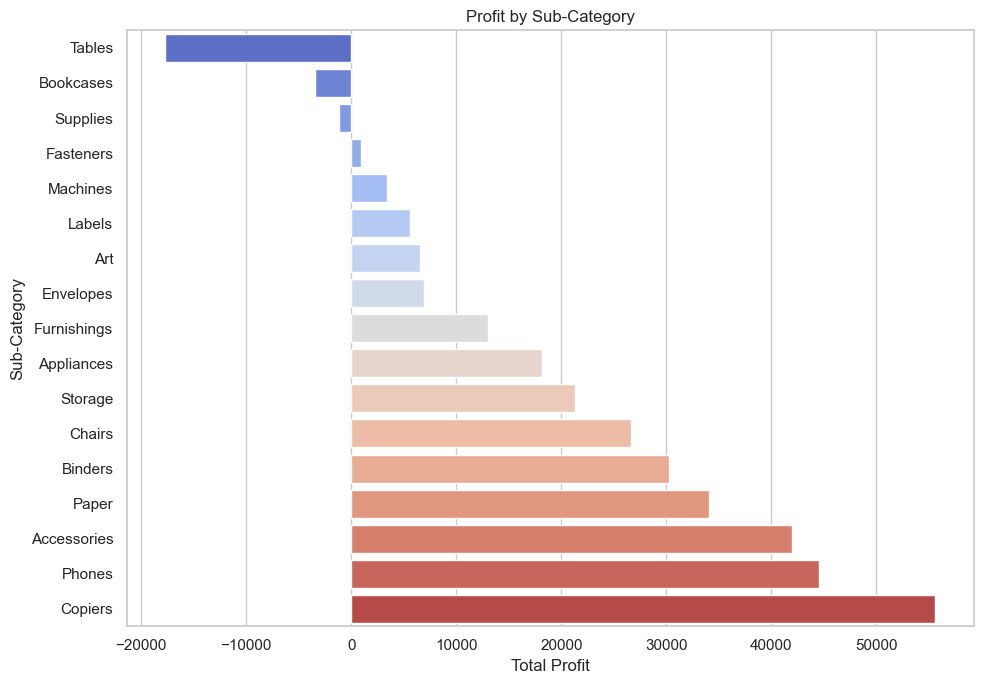

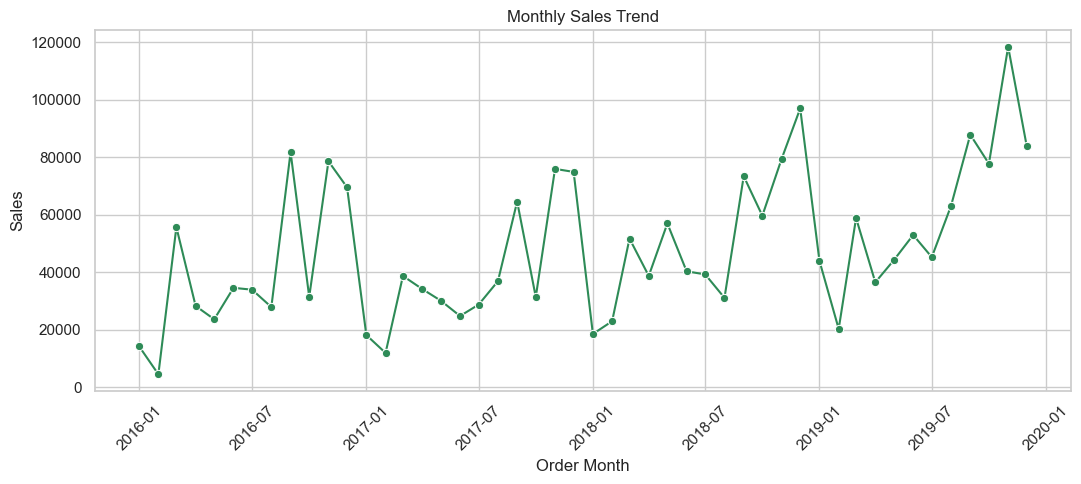

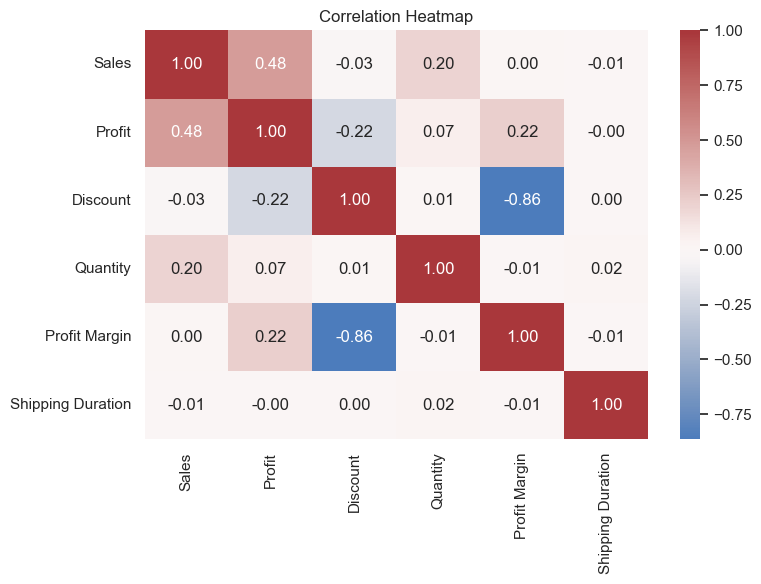

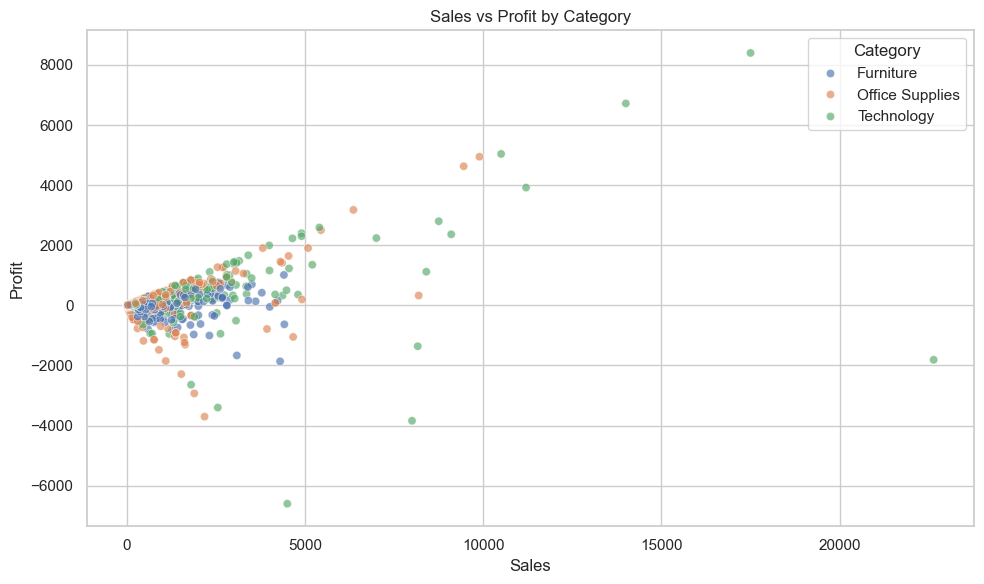

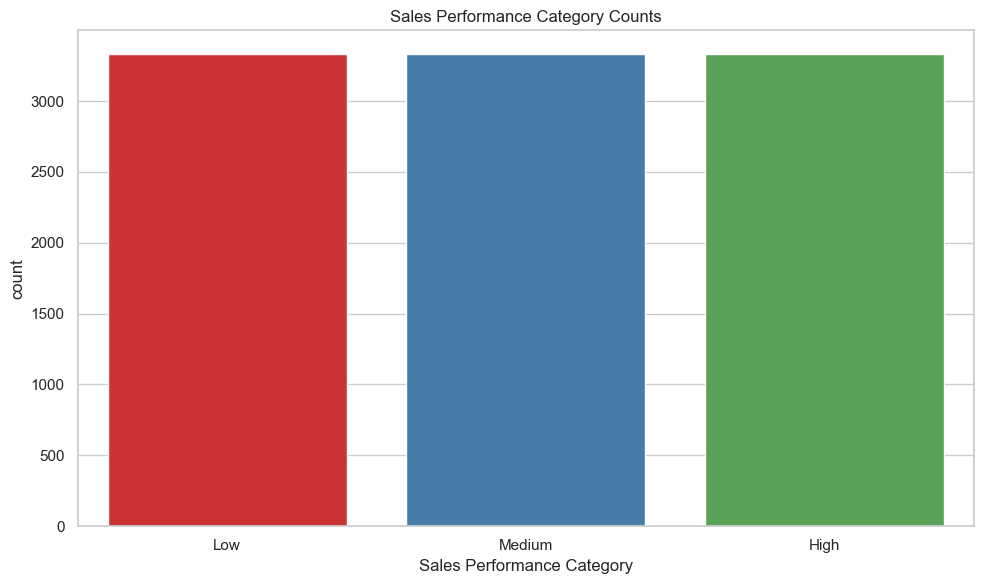

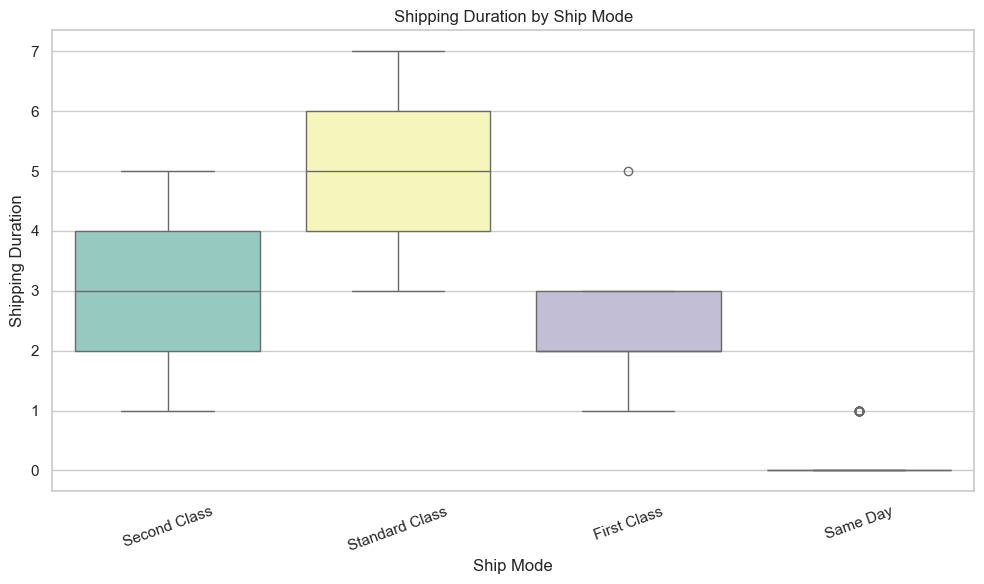

INFO:Saved 9 charts to C:\Users\o3995\Downloads\DEPI-R5\Technical\Projects\Mini-Project-1\output\charts


Saved 9 charts:
C:\Users\o3995\Downloads\DEPI-R5\Technical\Projects\Mini-Project-1\output\charts\01_sales_distribution.png
C:\Users\o3995\Downloads\DEPI-R5\Technical\Projects\Mini-Project-1\output\charts\02_profit_boxplot.png
C:\Users\o3995\Downloads\DEPI-R5\Technical\Projects\Mini-Project-1\output\charts\03_sales_by_category.png
C:\Users\o3995\Downloads\DEPI-R5\Technical\Projects\Mini-Project-1\output\charts\04_profit_by_subcategory.png
C:\Users\o3995\Downloads\DEPI-R5\Technical\Projects\Mini-Project-1\output\charts\05_monthly_sales_trend.png
C:\Users\o3995\Downloads\DEPI-R5\Technical\Projects\Mini-Project-1\output\charts\06_correlation_heatmap.png
C:\Users\o3995\Downloads\DEPI-R5\Technical\Projects\Mini-Project-1\output\charts\07_sales_profit_scatter.png
C:\Users\o3995\Downloads\DEPI-R5\Technical\Projects\Mini-Project-1\output\charts\08_sales_performance_counts.png
C:\Users\o3995\Downloads\DEPI-R5\Technical\Projects\Mini-Project-1\output\charts\09_shipping_duration_by_mode.png


In [20]:
visualizer = Visualizer(df_enriched, CHARTS_DIR)
chart_paths = visualizer.create_all()
print(f"Saved {len(chart_paths)} charts:")
for path in chart_paths:
    print(path)

### Visualization Notes
- Nine charts were created, exceeding the minimum requirement of eight.
- The charts cover distributions, outliers, category performance, sub-category profit, time trends, correlations, sales-profit relationships, performance categories, and shipping duration.

## Phase 7 - Automated KPI Summary & Report
Generate KPI summaries programmatically and export a readable text report.

In [21]:
class ReportGenerator:
    def __init__(self, data, output_dir):
        self.df = data.copy()
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)

    def kpis(self):
        total_sales = self.df['Sales'].sum()
        total_profit = self.df['Profit'].sum()
        return {
            'Total Sales': total_sales,
            'Total Profit': total_profit,
            'Overall Profit Margin': total_profit / total_sales if total_sales else 0,
            'Average Shipping Duration': self.df['Shipping Duration'].mean(),
            'Total Orders': self.df['Order ID'].nunique(),
            'Total Customers': self.df['Customer ID'].nunique(),
        }

    def top_items(self, group_col, metric, n=5, ascending=False):
        return (self.df.groupby(group_col, observed=True)[metric]
                .sum()
                .sort_values(ascending=ascending)
                .head(n))

    def build_report(self):
        try:
            kpis = self.kpis()
            best_region = self.top_items('Region', 'Profit', n=1).index[0]
            worst_region = self.top_items('Region', 'Profit', n=1, ascending=True).index[0]
            best_segment = self.top_items('Segment', 'Profit', n=1).index[0]

            lines = [
                'Mini-Project 1 - Automated KPI Summary',
                '=' * 43,
                f"Total Sales: ${kpis['Total Sales']:,.2f}",
                f"Total Profit: ${kpis['Total Profit']:,.2f}",
                f"Overall Profit Margin: {kpis['Overall Profit Margin']:.2%}",
                f"Average Shipping Duration: {kpis['Average Shipping Duration']:.2f} days",
                f"Total Orders: {kpis['Total Orders']:,}",
                f"Total Customers: {kpis['Total Customers']:,}",
                '',
                f"Best Region by Profit: {best_region}",
                f"Worst Region by Profit: {worst_region}",
                f"Best Segment by Profit: {best_segment}",
                '',
                'Top 5 Sub-Categories by Sales:',
            ]
            lines += [f'- {name}: ${value:,.2f}' for name, value in self.top_items('Sub-Category', 'Sales').items()]
            lines += ['', 'Top 5 Sub-Categories by Profit:']
            lines += [f'- {name}: ${value:,.2f}' for name, value in self.top_items('Sub-Category', 'Profit').items()]
            lines += ['', 'Bottom 5 Sub-Categories by Profit:']
            lines += [f'- {name}: ${value:,.2f}' for name, value in self.top_items('Sub-Category', 'Profit', ascending=True).items()]
            return '\n'.join(lines)
        except Exception as exc:
            logger.error('Report generation failed: %s', exc)
            raise exc

    def save_report(self, filename='report_summary.txt'):
        report = self.build_report()
        path = self.output_dir / filename
        path.write_text(report, encoding='utf-8')
        logger.info('Saved report to %s', path)
        return path, report


In [22]:
reporter = ReportGenerator(df_enriched, OUTPUT_DIR)
report_path, report_text = reporter.save_report()
print(report_text)

INFO:Saved report to C:\Users\o3995\Downloads\DEPI-R5\Technical\Projects\Mini-Project-1\output\report_summary.txt


Mini-Project 1 - Automated KPI Summary
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Overall Profit Margin: 12.47%
Average Shipping Duration: 3.96 days
Total Orders: 5,009
Total Customers: 793

Best Region by Profit: West
Worst Region by Profit: Central
Best Segment by Profit: Consumer

Top 5 Sub-Categories by Sales:
- Phones: $330,007.05
- Chairs: $328,449.10
- Storage: $223,843.61
- Tables: $206,965.53
- Binders: $203,412.73

Top 5 Sub-Categories by Profit:
- Copiers: $55,617.82
- Phones: $44,515.73
- Accessories: $41,936.64
- Paper: $34,053.57
- Binders: $30,221.76

Bottom 5 Sub-Categories by Profit:
- Tables: $-17,725.48
- Bookcases: $-3,472.56
- Supplies: $-1,189.10
- Fasteners: $949.52
- Machines: $3,384.76


### Report Notes
- The KPI report is generated automatically from the enriched dataset.
- The saved report includes total sales, total profit, overall profit margin, shipping duration, order/customer counts, and top/bottom sub-category performance.